## K-NN CLASSIFIER

k-NN finds the k most historical matches and uses them to decide who is likely to win

In [10]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler # because k-nn works with distances features need to have comparable scales
from sklearn.neighbors import KNeighborsClassifier

import sys
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from src.temporal_cv import (
    create_temporal_folds,
    validation_years
)

from src.evaluation import (
    evaluate_model
)

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

In [11]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = (
    PROCESSED_DATA_DIR / "feature_split_matches.csv"
)

matches = pd.read_csv(
    input_file, parse_dates = ["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print(matches["DataSplit"].value_counts())

Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [12]:
## create copies of the sets 
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

## check the periods
print(
    "Training:", 
    train_data["Date"].min(),
    "-",
    train_data["Date"].max()
)

print(
    "Validating:", 
    validation_data["Date"].min(),
    "-",
    validation_data["Date"].max()
)

print(
    "Testing:", 
    test_data["Date"].min(),
    "-",
    test_data["Date"].max()
)


Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validating: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Testing: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [13]:
assert(
    train_data["Date"].max() < validation_data["Date"].min()
)

assert(
    validation_data["Date"].max() < test_data["Date"].min()
)

print("Chronological order is maintained.")

Chronological order is maintained.


In [14]:
# The feature lists are imported from preprocessing.py.
# This ensures that all prediction models use
# exactly the same starting feature set.

print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw features:",
    len(numeric_features) + len(categorical_features)
)


Numerical features: 30
Categorical features: 5
Raw features: 35


In [15]:
##create temporal cross-validation folds for the training set
temporal_folds= create_temporal_folds(
    train_data,
    validation_years = validation_years
)

print(
    "Number of temporal folds created:", 
    len(temporal_folds)
)

pd.DataFrame(temporal_folds)

Number of temporal folds created: 4


,Fold,TrainingMatches,ValidationMatches,TrainingStartYear,TrainingEndYear,ValidationYear
0,1,10135,2497,2015,2018,2019
1,2,12632,1231,2015,2019,2020
2,3,13863,2402,2015,2020,2021
3,4,16265,2545,2015,2021,2022


In [16]:
##decide which values of k we want to try

## weights = "uniform" means every neighbor has the same vote
## weights = "distance" means closer neighbors have more influence

configurations = [
    {
        "name": "kNN k=11",
        "n_neighbors": 11,
        "weights": "uniform"
    },

    {
        "name": "kNN k=31",
        "n_neighbors": 31,
        "weights": "uniform"
    },

    {
        "name": "kNN k=51",
        "n_neighbors": 51,
        "weights": "uniform"
    },

    {
        "name": "kNN k=75",
        "n_neighbors": 75,
        "weights": "uniform"
    },

    {
        "name": "kNN k=101",
        "n_neighbors": 101,
        "weights": "uniform"
    },

    {
        "name": "kNN k=151",
        "n_neighbors": 151,
        "weights": "uniform"
    },

    {
        "name": "kNN k=11 distance",
        "n_neighbors": 11,
        "weights": "distance"
    },

    {
        "name": "kNN k=31 distance",
        "n_neighbors": 31,
        "weights": "distance"
    },

    {
        "name": "kNN k=51 distance",
        "n_neighbors": 51,
        "weights": "distance"
    },

    {
        "name": "kNN k=75 distance",
        "n_neighbors": 75,
        "weights": "distance"
    },

    {
        "name": "kNN k=101 distance",
        "n_neighbors": 101,
        "weights": "distance"
    },

    {
        "name": "kNN k=151",
        "n_neighbors": 151,
        "weights": "distance"
    }
]

In [17]:
print(
    "Configurations to test:",
    len(configurations)
)

Configurations to test: 12


now we create a list where we save  the results of each configuration and each fold

we have 12 configurations x 4 folds = 48 experiments in total

In [18]:
knn_cv_results = [] 

for configuration in configurations:
    print("Testing:",configuration["name"])

    for fold in temporal_folds:
        fold_number = (fold["Fold"])
        validation_year = (fold["ValidationYear"])

        fold_train = train_data.loc[
            train_data["Date"].dt.year < validation_year
        ].copy()

        fold_validation = train_data.loc[
            train_data["Date"].dt.year == validation_year
        ].copy()


        (
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        ) = fit_preprocessor (
            fold_train
        )

        X_fold_train = transform_data(
            fold_train,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )

        X_fold_validation = transform_data(
            fold_validation,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )

        # remember Player1Won = 1 means Player 1 won, Player1Won = 0 means Player 2 won
        y_fold_train = (fold_train["Player1Won"].to_numpy())
        y_fold_validation = (fold_validation["Player1Won"].to_numpy())

        fold_scaler = StandardScaler()

        X_fold_train[numeric_features] = fold_scaler.fit_transform(
            X_fold_train[numeric_features]
        )

        X_fold_validation[numeric_features] = fold_scaler.transform(
            X_fold_validation[numeric_features]
        )

        # we only use transform() for the validation because the scaler learns the means and std from the training set
        # we never do fit_tranform(X_fold_validation) because that would use validation information which would introduce bias

        current_model = KNeighborsClassifier(
            n_neighbors = configuration["n_neighbors"],
            weights = configuration["weights"],
            n_jobs = -1
        )

        current_model.fit(
            X_fold_train,
            y_fold_train
        )

        current_predictions = (
            current_model.predict(X_fold_validation)
        )

        current_probabilities = (
            current_model.predict_proba(X_fold_validation)[:, 1]
        )

        # the [:, 1] gives the probbaility of class 1

        current_fold_results = (
            evaluate_model(
                y_true = y_fold_validation,
                y_pred = current_predictions,
                model_name = configuration["name"],
                y_probability = current_probabilities
            ) # calculates accuracy, balanced accuracy, precision, etc.
        )

        current_fold_result = (
            current_fold_results.iloc[0].to_dict()
        )

        current_fold_result["Fold"] = fold_number
        current_fold_result["ValidationYear"] = validation_year
        current_fold_result["Neighbors"] = configuration["n_neighbors"]
        current_fold_result["Weights"] = configuration["weights"]

        knn_cv_results.append(current_fold_result)

        print(
            "Fold", 
            fold_number,
            "year",
            validation_year,
            "accuracy:",
            round(current_fold_result["Accuracy"], 4)
        )

print(
    "\nTotal results collected:",
    len(knn_cv_results)
)

Testing: kNN k=11
Fold 1 year 2019 accuracy: 0.6127
Fold 2 year 2020 accuracy: 0.6117
Fold 3 year 2021 accuracy: 0.5966
Fold 4 year 2022 accuracy: 0.6181
Testing: kNN k=31
Fold 1 year 2019 accuracy: 0.6187
Fold 2 year 2020 accuracy: 0.6296
Fold 3 year 2021 accuracy: 0.6162
Fold 4 year 2022 accuracy: 0.6436
Testing: kNN k=51
Fold 1 year 2019 accuracy: 0.6223
Fold 2 year 2020 accuracy: 0.6304
Fold 3 year 2021 accuracy: 0.6216
Fold 4 year 2022 accuracy: 0.6475
Testing: kNN k=75
Fold 1 year 2019 accuracy: 0.6243
Fold 2 year 2020 accuracy: 0.632
Fold 3 year 2021 accuracy: 0.6241
Fold 4 year 2022 accuracy: 0.6503
Testing: kNN k=101
Fold 1 year 2019 accuracy: 0.6223
Fold 2 year 2020 accuracy: 0.632
Fold 3 year 2021 accuracy: 0.6153
Fold 4 year 2022 accuracy: 0.6582
Testing: kNN k=151
Fold 1 year 2019 accuracy: 0.6284
Fold 2 year 2020 accuracy: 0.632
Fold 3 year 2021 accuracy: 0.6261
Fold 4 year 2022 accuracy: 0.6621
Testing: kNN k=11 distance
Fold 1 year 2019 accuracy: 0.6123
Fold 2 year 2020

**ANALYSIS**

we notice that with an increasing k our accuracy increases until we reach a value of k = 201, where with a uniform weight across all values we notice a decrease, while with values weighted differently it maintains a uniform andamento

In [19]:
# convert results into a dataframe

knn_cv_fold_results = pd.DataFrame(knn_cv_results)

print("Configurations: ", len(configurations))
print("Temporal folds: ", len(temporal_folds))
print("Results: ", len(knn_cv_fold_results))

Configurations:  12
Temporal folds:  4
Results:  48


In [20]:
assert(len(knn_cv_fold_results) == len(configurations) * len(temporal_folds))

In [21]:
knn_cv_fold_results.head()

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss,Fold,ValidationYear,Neighbors,Weights
0,kNN k=11,0.612735,0.612758,0.608140,0.615509,0.611802,0.646124,0.744988,1,2019,11,uniform
1,kNN k=11,0.611698,0.612311,0.633943,0.596244,0.614516,0.651575,0.806380,2,2020,11,uniform
2,kNN k=11,0.596586,0.596524,0.577441,0.594970,0.586074,0.634320,0.834791,3,2021,11,uniform
3,kNN k=11,0.618075,0.617911,0.620861,0.593354,0.606796,0.664639,0.709379,4,2022,11,uniform
4,kNN k=31,0.618742,0.618567,0.619765,0.597738,0.608553,0.664799,0.648397,1,2019,31,uniform


In [22]:
print(len(knn_cv_fold_results))

48


In [23]:
knn_cv_summary = (
    knn_cv_fold_results.groupby(
        ["Model", "Neighbors", "Weights"],
        as_index = False
    ).agg(
        MeanAccuracy = ("Accuracy", "mean"),
        StdAccuracy = ("Accuracy", "std"),
        MeanBalancedAccuracy = ("BalancedAccuracy", "mean"),
        MeanF1Score = ("F1", "mean"),
        MeanROC_AUC = ("ROC-AUC", "mean"),
        MeanLogLoss = ("LogLoss", "mean")
    )
)

In [24]:
knn_cv_summary = (
    knn_cv_summary.sort_values(
        by = ["MeanAccuracy", "MeanROC_AUC"],
        ascending = [False, False]
    ).reset_index(drop = True)
)

In [25]:
knn_cv_summary

,Model,Neighbors,Weights,MeanAccuracy,StdAccuracy,MeanBalancedAccuracy,MeanF1Score,MeanROC_AUC,MeanLogLoss
0,kNN k=151,151,uniform,0.637147,0.016798,0.637157,0.625480,0.693629,0.631763
1,kNN k=151,151,distance,0.635204,0.017568,0.635197,0.623547,0.693853,0.631453
2,kNN k=75,75,uniform,0.632678,0.012307,0.632568,0.622035,0.690567,0.632155
3,kNN k=101,101,uniform,0.631957,0.018756,0.631867,0.619810,0.692153,0.631652
4,kNN k=101 distance,101,distance,0.631648,0.018610,0.631522,0.619144,0.692285,0.631514
5,kNN k=51 distance,51,distance,0.631345,0.012961,0.631229,0.620011,0.684281,0.635971
6,kNN k=75 distance,75,distance,0.630641,0.014309,0.630421,0.619795,0.690533,0.632165
7,kNN k=51,51,uniform,0.630460,0.012067,0.630342,0.619509,0.684188,0.636056
8,kNN k=31 distance,31,distance,0.628053,0.012085,0.628173,0.618140,0.675764,0.641913
9,kNN k=31,31,uniform,0.627020,0.012497,0.627075,0.616762,0.675614,0.641879


In [26]:
# select the best configuration automatically

best_model_name = (knn_cv_summary.iloc[0]["Model"])

best_configuration = next(
    configuration
    for configuration in configurations
    if configuration["name"] == best_model_name
)

print("Selected k-NN: best_model_name")

best_configuration

Selected k-NN: best_model_name


{'name': 'kNN k=151', 'n_neighbors': 151, 'weights': 'uniform'}

we are now done with hyperparameter selection so now we can use the complete 2015-2022 training set to train the selected model

In [27]:
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

y_train = (train_data["Player1Won"].to_numpy())
y_validation = (validation_data["Player1Won"].to_numpy())

In [28]:
print(
    "Training X:",
    X_train.shape
)

print(
    "Validation X:",
    X_validation.shape
)

Training X: (18810, 50)
Validation X: (2607, 50)


In [29]:
assert (X_train.isna().sum().sum() == 0)
assert (X_validation.isna().sum().sum() == 0)

In [30]:
knn_scaler = StandardScaler()

X_fold_train[numeric_features] = fold_scaler.fit_transform(
    X_fold_train[numeric_features]
)

X_fold_validation[numeric_features] = fold_scaler.transform(
    X_fold_validation[numeric_features]
)

print("k-NN scaling completed")

k-NN scaling completed


In [31]:
best_knn = KNeighborsClassifier( # build the best knn
    n_neighbors = best_configuration["n_neighbors"],
    weights = best_configuration["weights"],
    n_jobs = -1
)

best_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",151
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",-1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [32]:
#predict the external 2023 validation set

best_validation_predictions = (
    best_knn.predict(X_validation)
)

best_validation_probabilities = (
    best_knn.predict_proba(X_validation)[:, 1]
)

In [33]:
print(
    classification_report(
        y_validation,
        best_validation_predictions,
        target_names = ["Player 2 wins", "Player 1 wins"],
        zero_division = 0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.65      0.64      0.65      1368
Player 1 wins       0.61      0.62      0.62      1239

     accuracy                           0.63      2607
    macro avg       0.63      0.63      0.63      2607
 weighted avg       0.63      0.63      0.63      2607



In [34]:
best_knn_result = evaluate_model(
    y_true = y_validation,
    y_pred = (best_validation_predictions),
    model_name = (best_model_name),
    y_probability = (best_validation_probabilities)
)

best_knn_result

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,kNN k=151,0.631377,0.630986,0.609795,0.623083,0.616367,0.689617,0.63466


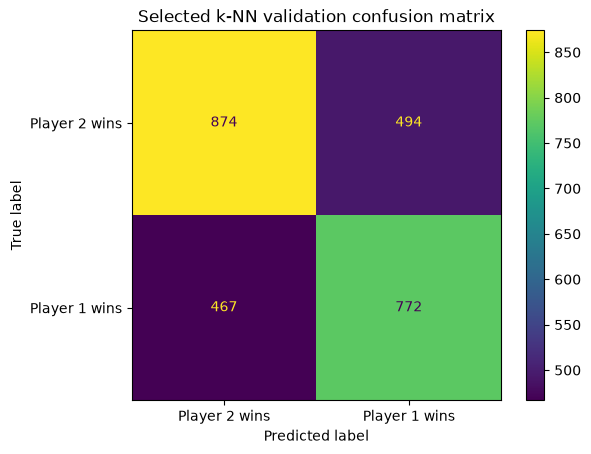

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    best_validation_predictions,
    display_labels = ["Player 2 wins", "Player 1 wins"],
    values_format = "d"
)

plt.title("Selected k-NN validation confusion matrix")
plt.show()

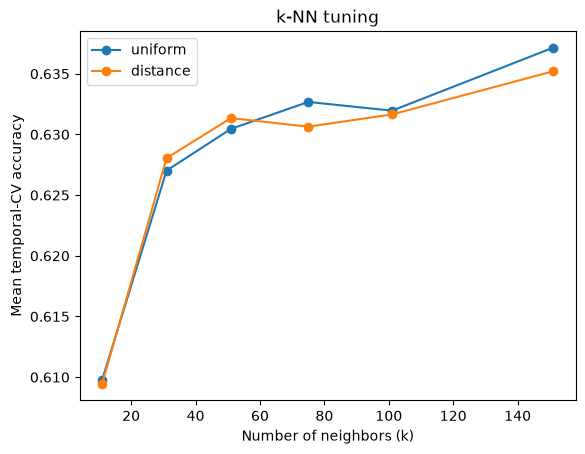

In [36]:
for weight_type in["uniform", "distance"]:
    plot_data = (
        knn_cv_summary.loc[
            knn_cv_summary["Weights"] == weight_type
        ].sort_values("Neighbors")
    )

    plt.plot(
        plot_data["Neighbors"],
        plot_data["MeanAccuracy"],
        marker = "o",
        label = weight_type
    )

plt.xlabel("Number of neighbors (k)")
plt.ylabel("Mean temporal-CV accuracy")
plt.title("k-NN tuning")
plt.legend()
plt.show()

In [37]:
RESULTS_DIR = Path("../results")

MODELS_DIR = Path("../models")

knn_cv_fold_results.to_csv(
    RESULTS_DIR / "knn_cv_fold_results.csv",
    index = False
)

knn_cv_summary.to_csv(
    RESULTS_DIR / "best_knn_results.csv",
    index = False
)

In [38]:
import joblib

joblib.dump(
    best_knn,
    MODELS_DIR / "best_knn_validation.joblib"
)

joblib.dump(
    knn_scaler,
    MODELS_DIR / "best_knn_scaler.joblib"
)

['..\\models\\best_knn_scaler.joblib']

In [39]:
print("k-NN TEMPORAL CV")

print(knn_cv_summary)

print("\nSelected configuration:", best_model_name)

print("\nExternal 2023 validation")

print(best_knn_result)

k-NN TEMPORAL CV
                 Model  Neighbors   Weights  MeanAccuracy  StdAccuracy  \
0            kNN k=151        151   uniform      0.637147     0.016798   
1            kNN k=151        151  distance      0.635204     0.017568   
2             kNN k=75         75   uniform      0.632678     0.012307   
3            kNN k=101        101   uniform      0.631957     0.018756   
4   kNN k=101 distance        101  distance      0.631648     0.018610   
5    kNN k=51 distance         51  distance      0.631345     0.012961   
6    kNN k=75 distance         75  distance      0.630641     0.014309   
7             kNN k=51         51   uniform      0.630460     0.012067   
8    kNN k=31 distance         31  distance      0.628053     0.012085   
9             kNN k=31         31   uniform      0.627020     0.012497   
10            kNN k=11         11   uniform      0.609773     0.009225   
11   kNN k=11 distance         11  distance      0.609462     0.010451   

    MeanBalancedAccu